In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

Funkcja do wyznaczania projekcji PCA i TSNE

In [2]:
def compute_embeddings(X, n_components=2, random_state=0):
    pca = PCA(n_components=n_components, random_state=random_state)
    emb_pca = pca.fit_transform(X)
    tsne = TSNE(
        n_components=n_components,
        init="pca",
        learning_rate="auto",
        perplexity=30,
        random_state=random_state,
    )
    emb_tsne = tsne.fit_transform(X)
    return emb_pca, emb_tsne

Zbiór MNIST (digits) - rozpoznawanie odręcznie pisanych cyfr - klasyczny zbiór do demonstracji i testowania metod ML

![MNIST](mnist.jpg)

Zbiór WINE - rozpoznawanie regionu pochodzenia wina po parametrach fizykochemicznych - kolejny klasyczny zbiór

![WINE](wine_features.jpg)

Wczytanie zbiorów i wyznaczenie projekcji

In [3]:
X_digits, y_digits = load_digits(return_X_y=True)
emb_pca_digits, emb_tsne_digits = compute_embeddings(X_digits)
    
X_wine, y_wine = load_wine(return_X_y=True)
X_wine_scaled = StandardScaler().fit_transform(X_wine)
emb_pca_wine, emb_tsne_wine = compute_embeddings(X_wine_scaled)

Wyswieltanie kolejnych scenariuszy

In [4]:
def plot_single(emb, title, y=None):
    plt.figure(figsize=(4, 4))
    if y is None:
        plt.scatter(emb[:, 0], emb[:, 1], c='k', s=60, alpha=0.5)  
    else:
        plt.scatter(emb[:, 0], emb[:, 1], c=y, cmap='tab10', 
                    s=60, alpha=0.5)
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    plt.title(title)
    plt.tight_layout()
    plt.show()

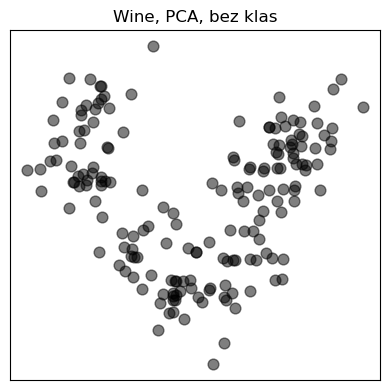

In [5]:
plot_single(emb_pca_wine, 'Wine, PCA, bez klas')

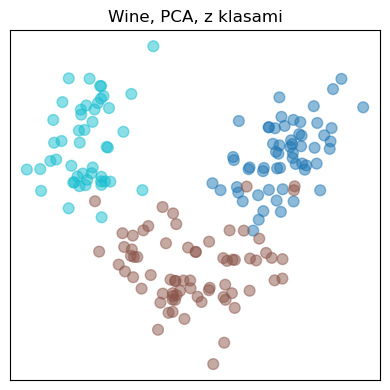

In [6]:
plot_single(emb_pca_wine, 'Wine, PCA, z klasami', y_wine)

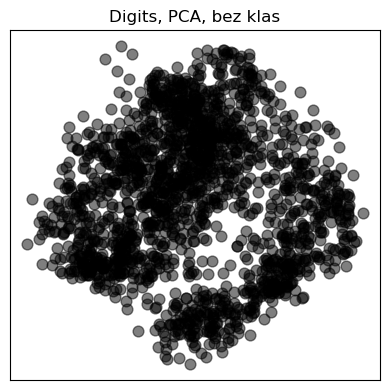

In [7]:
plot_single(emb_pca_digits, 'Digits, PCA, bez klas')

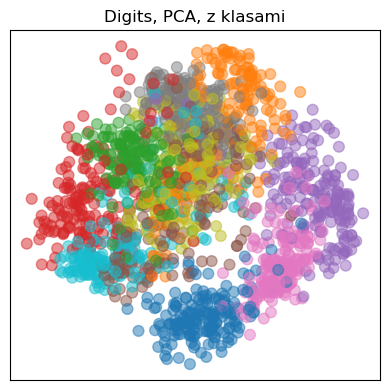

In [8]:
plot_single(emb_pca_digits, 'Digits, PCA, z klasami', y_digits)

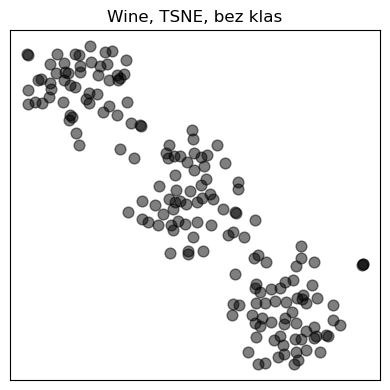

In [9]:
plot_single(emb_tsne_wine, 'Wine, TSNE, bez klas')

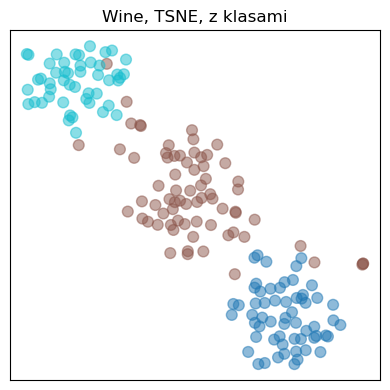

In [10]:
plot_single(emb_tsne_wine, 'Wine, TSNE, z klasami', y_wine)

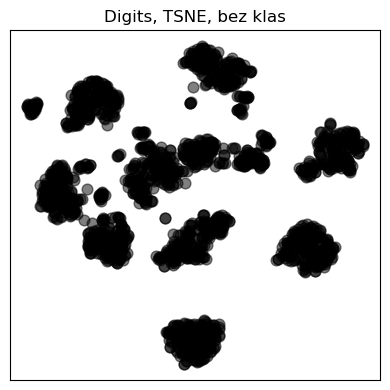

In [11]:
plot_single(emb_tsne_digits, 'Digits, TSNE, bez klas')

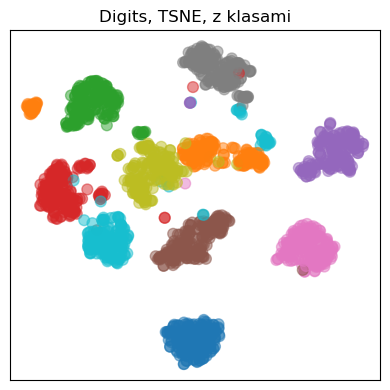

In [12]:
plot_single(emb_tsne_digits, 'Digits, TSNE, z klasami', y_digits)